In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
%matplotlib inline  
# %ensures that any plots generated by Matplotlib or Seaborn will be displayed directly inside the notebook.
from sklearn.datasets import fetch_california_housing
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
housing_bunch=fetch_california_housing()
print("Keys available in object:")
print(housing_bunch.keys())

Keys available in object:
dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [3]:
print(housing_bunch.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
housing_df=pd.DataFrame(data=housing_bunch.data, columns=housing_bunch.feature_names)
housing_df['MedHouseVal']=housing_bunch.target
print("Dataframes created successfully.")
print(f"Dataframe has {housing_df.shape[0]} rows and {housing_df.shape[1]} columns.")

Dataframes created successfully.
Dataframe has 20640 rows and 9 columns.


In [5]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
housing_df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [7]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


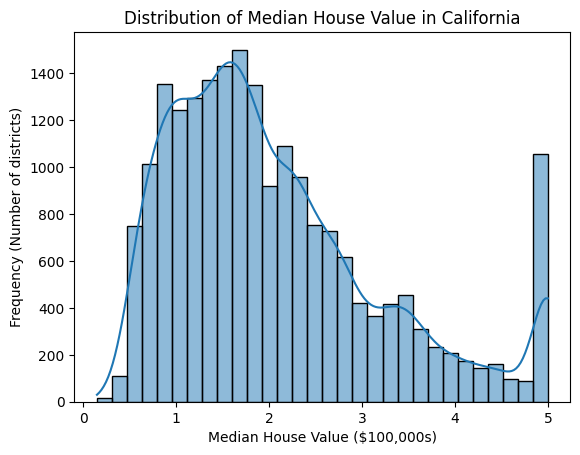

In [9]:
plt.Figure(figsize=(10,8))
sns.histplot(data=housing_df,x='MedHouseVal',bins=30,kde=True)
# x is the column we want from dataframe
# kde: Kernel Density Estimate. This adds a smoothed line over the histogram to better visualize the shape of the distribution.
plt.title("Distribution of Median House Value in California")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel('Frequency (Number of districts)')
plt.show()

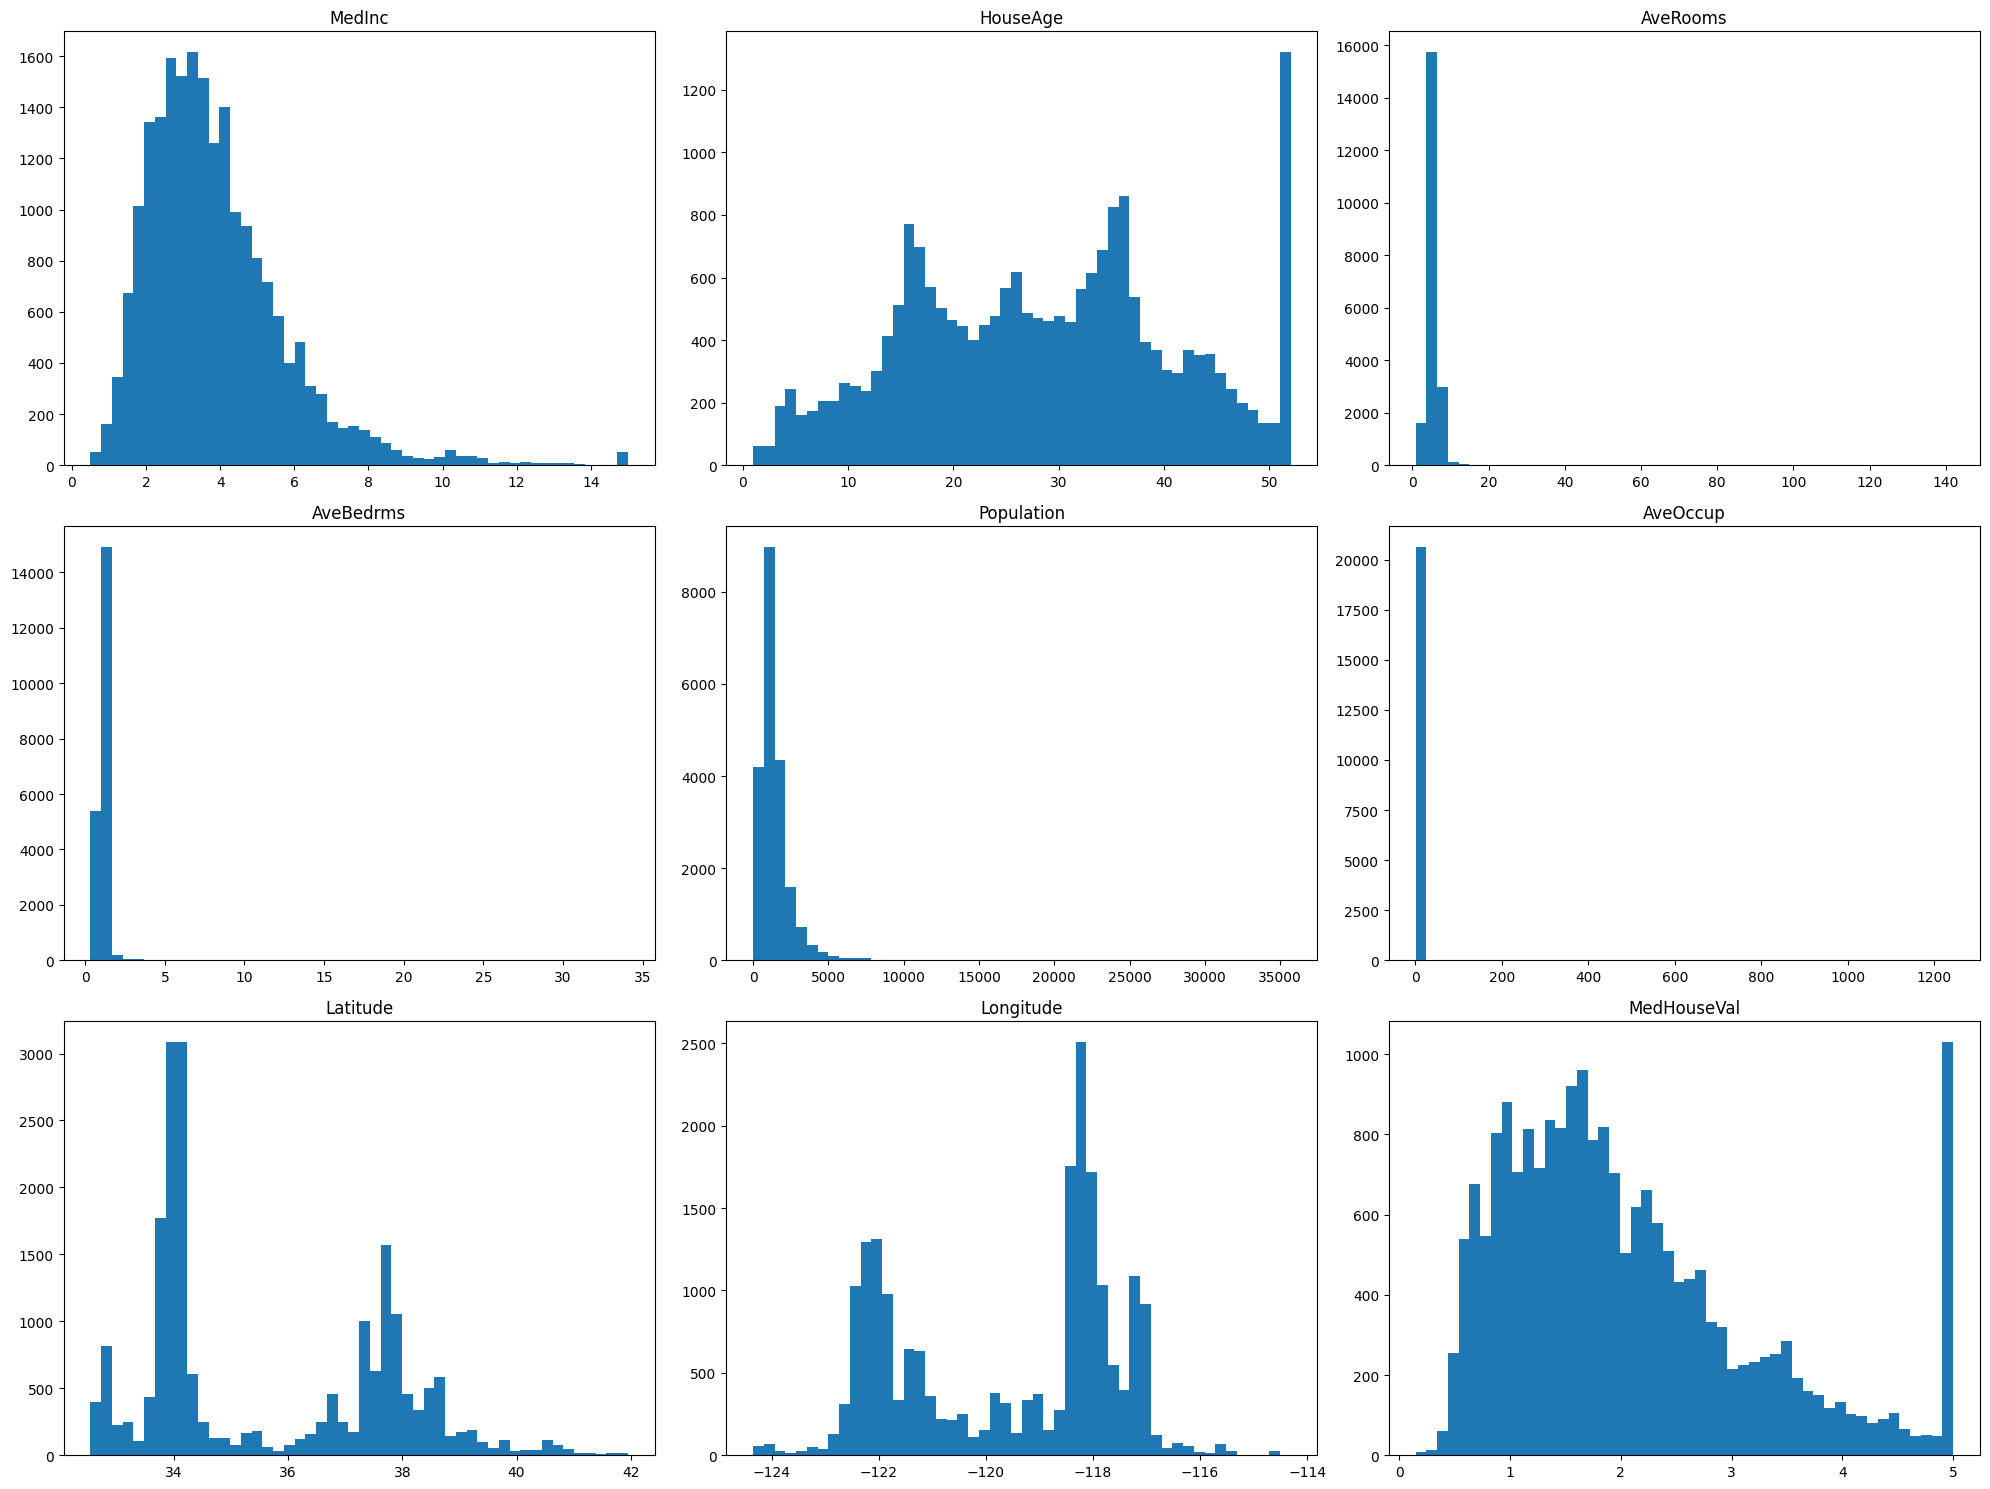

In [10]:
housing_df.hist(bins=50, figsize=(20,15),grid=False)
# grid=False: This is a stylistic choice to remove the background grid lines, which can sometimes make plots look cluttered.
plt.tight_layout()
# The plt.tight_layout() function from Matplotlib automatically adjusts the spacing between subplots to prevent titles, labels, or 
# axes from overlapping.
plt.show()

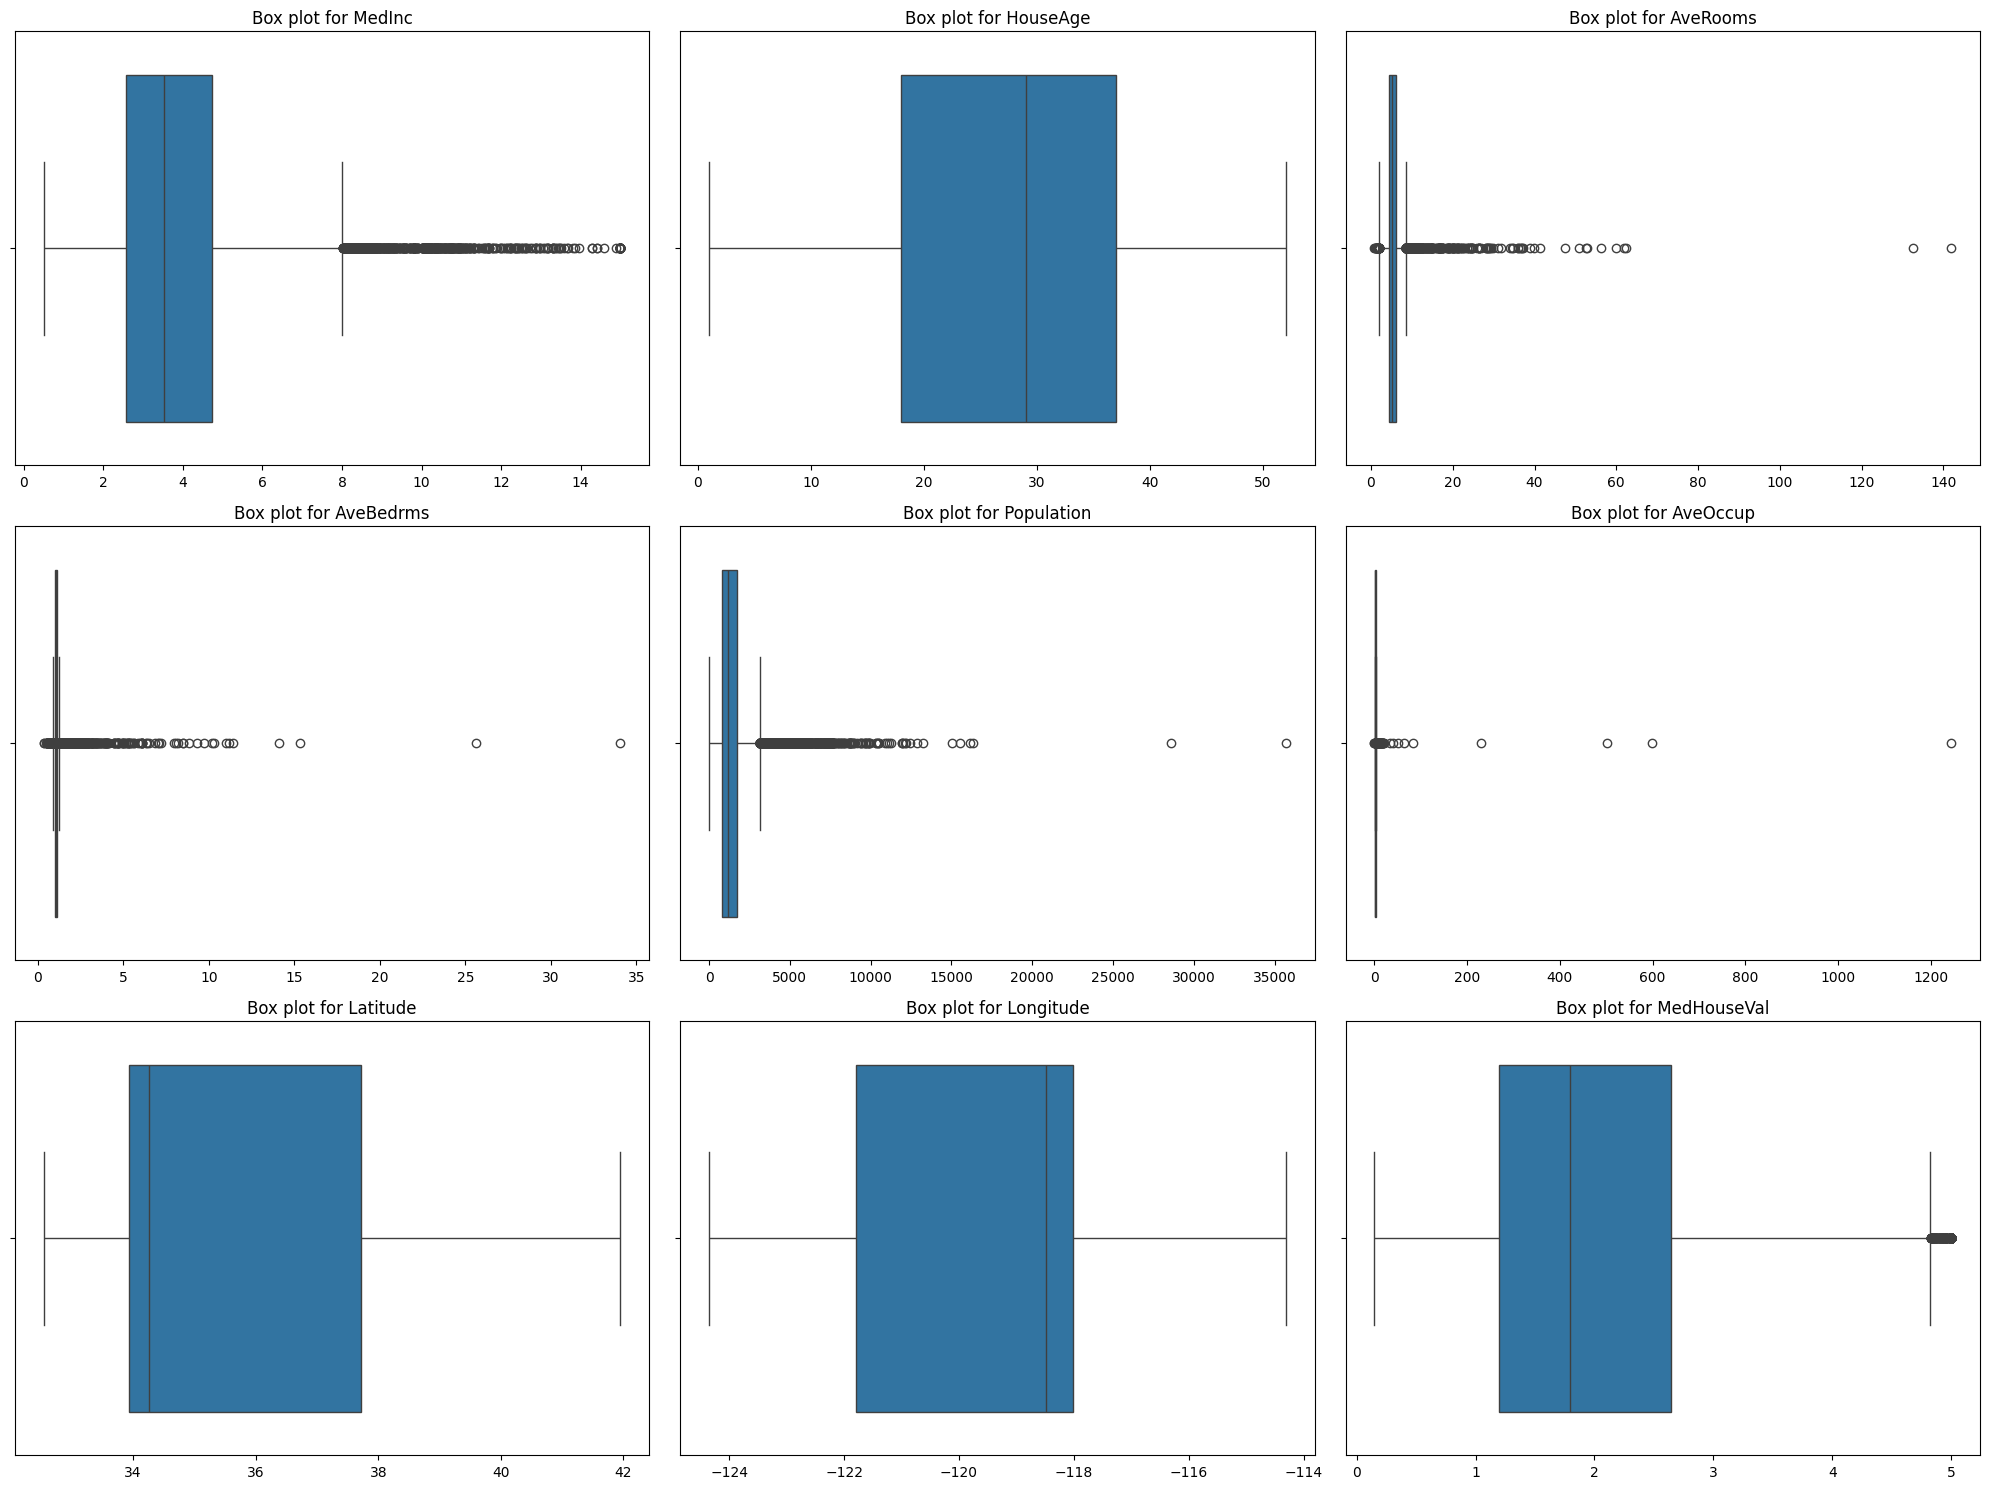

In [11]:
fig, axes=plt.subplots(nrows=3,ncols=3, figsize=(20,15))
axes=axes.flatten()
# The `axes` object is a 2D NumPy array of plot objects. We can flatten it into a 1D array to make it easier to loop over.

# Loop through each column in the DataFrame and its corresponding subplot axis.
# `zip` is a handy function that pairs up elements from two lists.
for col, ax in zip(housing_df.columns, axes):
    # Create a box plot for the current column `col` on the current axis `ax`.
    sns.boxplot(x=housing_df[col],ax=ax)
    ax.set_title(f'Box plot for {col}', fontsize=12)
    ax.set_xlabel('')

# This command adjusts the padding between and around subplots to prevent overlap.
plt.tight_layout()
plt.show()

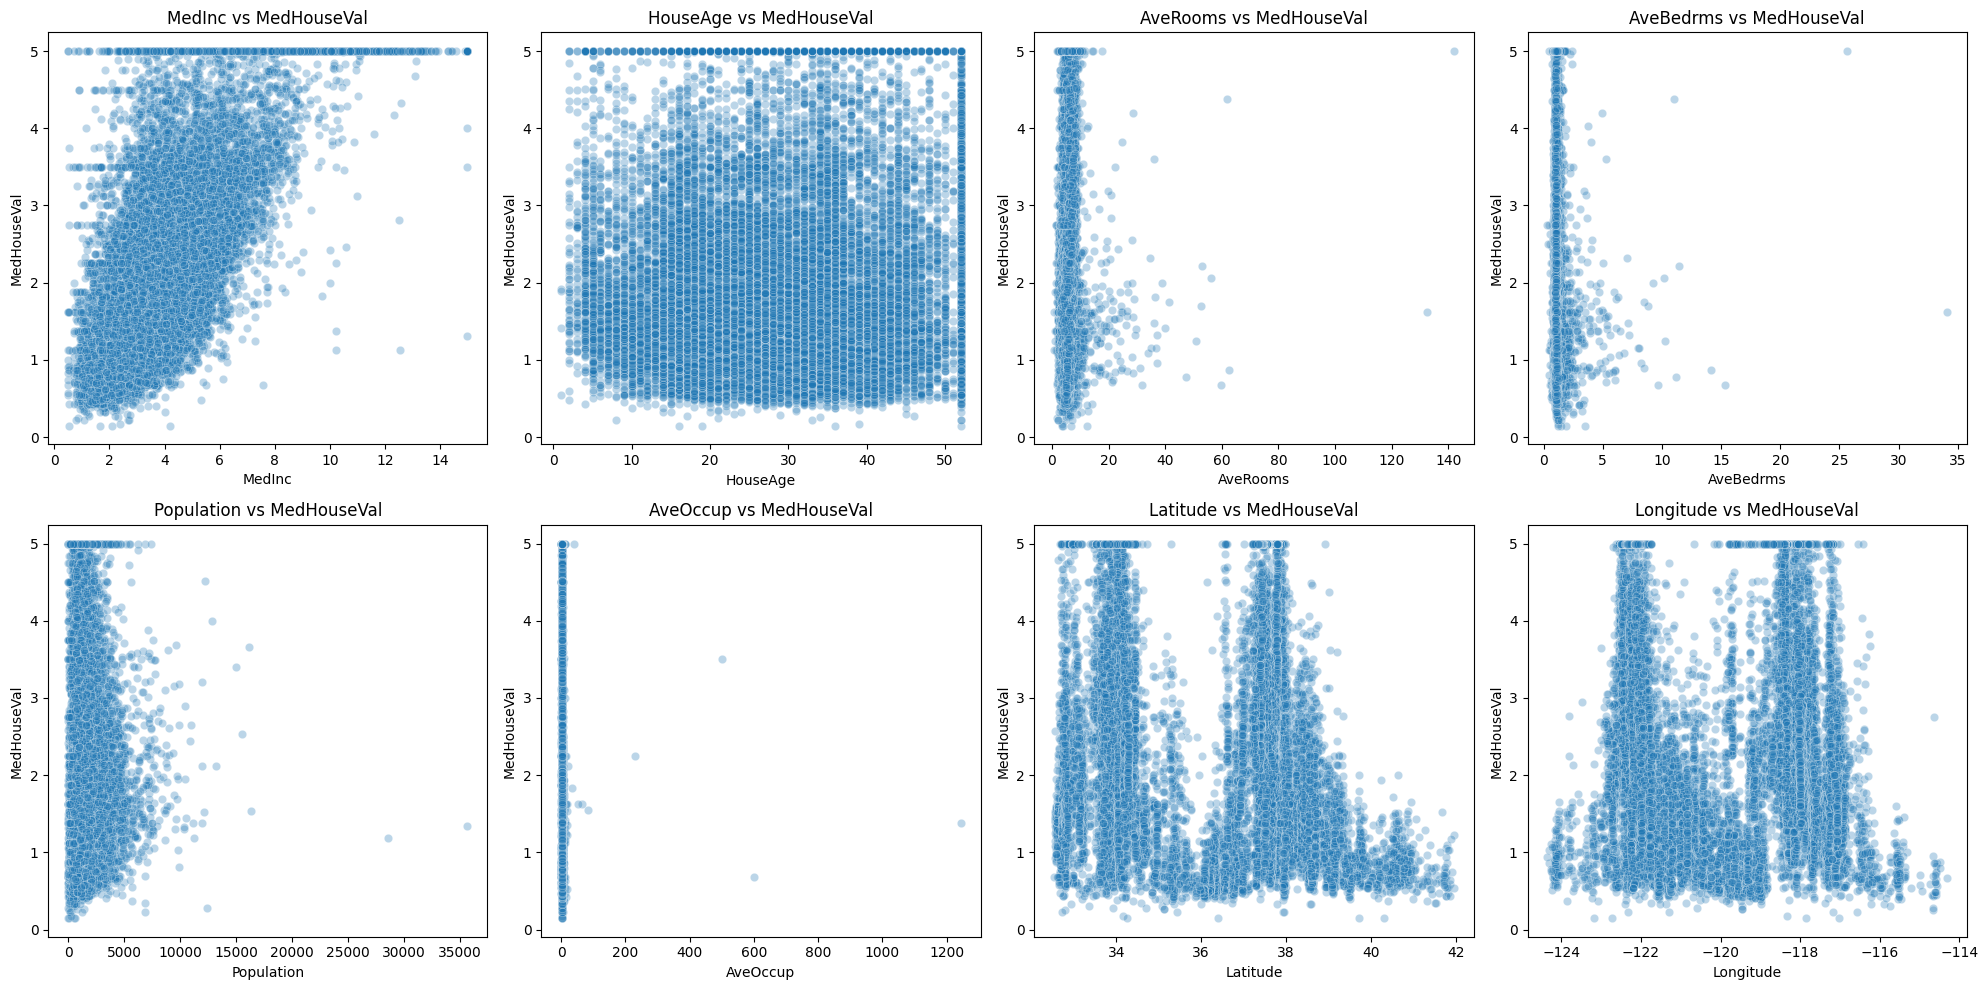

In [12]:
features=housing_df.columns.drop('MedHouseVal')
target='MedHouseVal'
fig, axes=plt.subplots(nrows=2,ncols=4,figsize=(20,10))
axes=axes.flatten()
for i, feature in enumerate(features):
    sns.scatterplot(x=feature,y=target,data=housing_df,ax=axes[i],alpha=0.3)
    # alpha: Sets the transparency of the points. 0.3 means 30% opacity.
    axes[i].set_title(f"{feature} vs {target}")

plt.tight_layout()
plt.show()

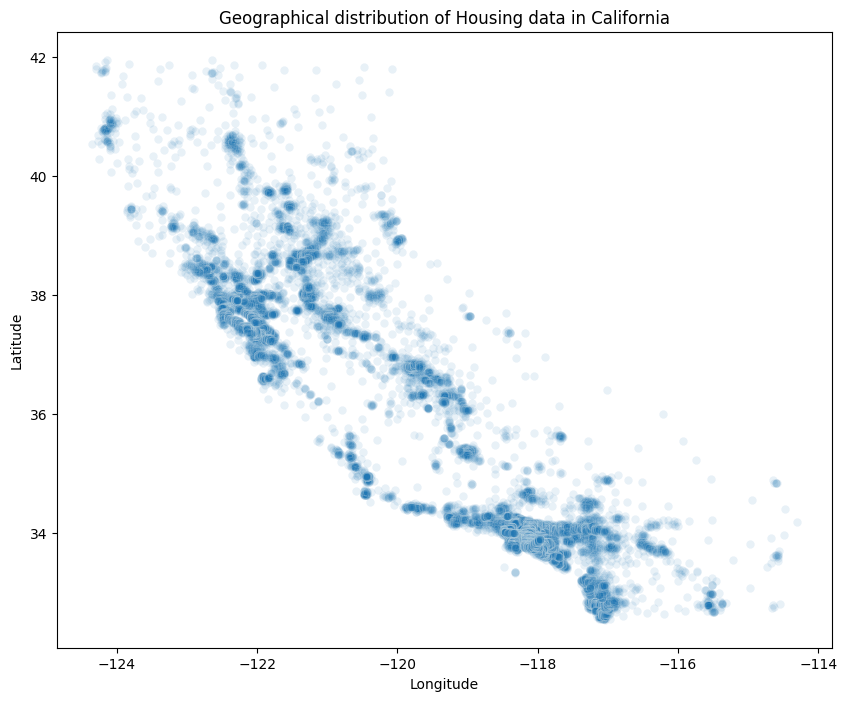

In [13]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=housing_df,y='Latitude',x='Longitude',alpha=0.1)
 #Here is the crucial parameter for handling overplotting. A low alpha value makes points transparent, so areas with many points become darker.
plt.title("Geographical distribution of Housing data in California")
plt.ylabel("Latitude")
plt.xlabel("Longitude")
plt.show()

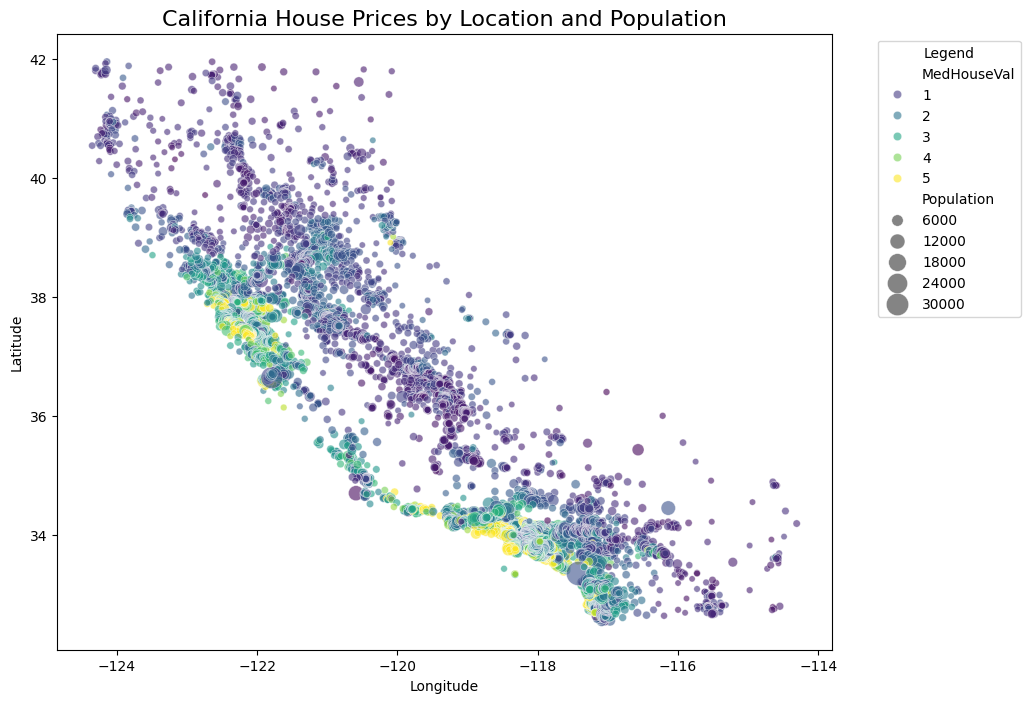

In [14]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=housing_df,x='Longitude',y='Latitude',hue='MedHouseVal',size='Population',palette='viridis',sizes=(20,300),alpha=0.6 )
# `hue` will color the points based on the 'MedHouseVal' column.
# `size` will adjust the size of the points based on the 'Population' column.
# `palette` specifies the color map. 'viridis' is a good choice for continuous data as it's visually appealing and accessible to colorblind viewers.
plt.title("California House Prices by Location and Population",fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Legend",bbox_to_anchor=(1.05,1),loc='upper left')
plt.show()

In [15]:
corr_matrix=housing_df.corr()
# The .corr() method calculates the pairwise correlation of columns, excluding NA/null values. By default, it uses the Pearson correlation coefficient.
print("Correlation with Target Variable (MedHouseVal):")
corr_matrix['MedHouseVal'].sort_values(ascending=False)

Correlation with Target Variable (MedHouseVal):


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

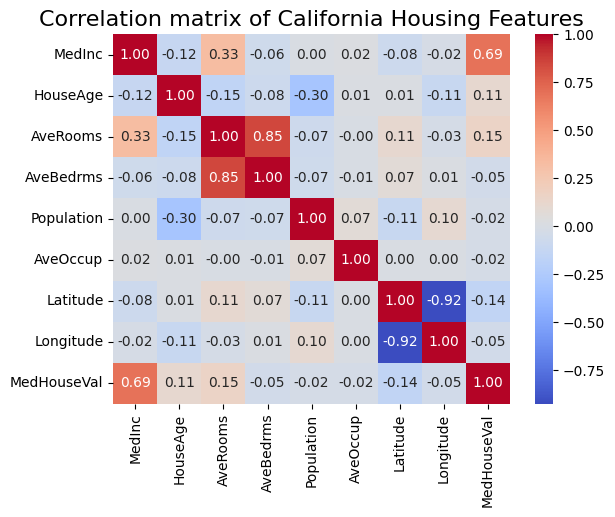

In [16]:
plt.Figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
# corr_matrix: The correlation matrix we calculated in the previous step.
# annot=True: Displays the correlation coefficient on each cell of the heatmap, making it highly informative.
# cmap='coolwarm': This specifies the color map. 'coolwarm' is a "diverging" palette, It uses a cool color (blue)
# for negative correlations, a warm color (red) for positive correlation and a neutral color (light gray/white) for correlations near zero.
# fmt='.2f': Formats the annotations to two decimal places for a cleaner look.
plt.title("Correlation matrix of California Housing Features",fontsize=16)
plt.show()

In [17]:
#Median Income (MedInc) is the Strongest Predictor:

#Correlation: +0.69
#Interpretation: This is a strong positive correlation. The most influential feature in our dataset for predicting house prices. 
#The number 0.69 quantifies the clear upward trend we saw in its scatter plot against MedHouseVal. 
# As the median income in a district rises, the median house value tends to rise significantly as well. 
#Any machine learning model we build will almost certainly rely heavily on this feature.

#Average Rooms (AveRooms) has a Weak Positive Influence:

#Correlation: +0.15
#Interpretation: There is a slight, but very weak, tendency for districts with a higher average number of rooms to have higher house values. 
#The relationship is not strong, which we also saw in the very scattered scatter plot for this feature. 
# While it might provide some value, it is far less important than MedInc.
#Latitude has a Weak Negative Influence:

#Correlation: -0.14
# Interpretation: This is the most significant negative correlation. 
# It suggests that as we move north (latitude increases), house prices tend to decrease slightly. 
# This is a general trend across the entire state and doesn't capture local variations (like the expensive Bay Area). 
# It's an interesting geographical insight that a model might be able to use.
# All Other Features Have Very Weak Linear Relationships:

#Interpretation: Features like HouseAge, Population, AveOccup, Longitude, and AveBedrms all have correlation coefficients very close to zero. 
# This tells us they have almost no linear relationship with the median house value on their own. 
# This is a critical insight. 
# It does not mean these features are useless—they could have non-linear relationships or be important in combination with other features (a concept called "interaction effects"). 
# However, we now know not to expect them to be powerful drivers in a simple linear model.

In [18]:
missing_values=housing_df.isnull().sum()
# The .isnull() method returns a DataFrame of booleans (True for missing, False for not missing).
# Chaining .sum() on this boolean DataFrame counts the number of 'True' values in each column.
print("Missing values in each columns:")
print(missing_values)

Missing values in each columns:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [19]:
# In a real machine learning project, you would split your data into training and
# testing sets BEFORE any preprocessing. You would then .fit() the imputer ONLY
# on the training data to prevent "data leakage" from the test set.
# For this educational step, we will apply it to the whole DataFrame to learn the mechanics.

# We create an instance of the SimpleImputer, telling it to use the 'median' strategy. This aligns with the decision we made in the previous task.
imputer=SimpleImputer(strategy='median')

# We use .fit_transform() on our DataFrame. The imputer will first calculate the median of each column ('fit') and then
# check for and replace any missing values with those medians ('transform'). The output of a scikit-learn transformer is typically a NumPy array, 
# not a pandas DataFrame.
housing_imputed_np=imputer.fit_transform(housing_df)

# It's crucial to convert the result back to a DataFrame to retain our column names and index, which are essential for further analysis.
# We create a new DataFrame, passing the NumPy array as data and reusing the original column names and index from housing_df.
housing_df_imputed=pd.DataFrame(housing_imputed_np,columns=housing_df.columns,index=housing_df.index)

print("Dataframe after applying imputer (first 5 rows)")
housing_df_imputed.head()

Dataframe after applying imputer (first 5 rows)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [20]:
housing_df_imputed['rooms_per_person']=housing_df_imputed['AveRooms']/housing_df_imputed['AveOccup']
print("Dataframe with new feature (rooms_per_person)")
housing_df_imputed.head()

Dataframe with new feature (rooms_per_person)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,rooms_per_person
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646


In [21]:
#Feature Enginerring: Adding new features to dataframe
print("\nStatistical summary of new feature")
housing_df_imputed['rooms_per_person'].describe()


Statistical summary of new feature


count    20640.000000
mean         1.976970
std          1.146020
min          0.002547
25%          1.522382
50%          1.937936
75%          2.296090
max         55.222222
Name: rooms_per_person, dtype: float64

In [22]:
housing_df_imputed['bedrooms_per_room']=housing_df_imputed['AveBedrms']/housing_df_imputed['AveRooms']
print("Dataframe with new featues (bedrooms_per_room)")
display(housing_df_imputed.head())
print("Statistical summary of new feature")
display(housing_df_imputed['bedrooms_per_room'].describe())

Dataframe with new featues (bedrooms_per_room)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,rooms_per_person,bedrooms_per_room
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096


Statistical summary of new feature


count    20640.000000
mean         0.213075
std          0.058023
min          0.100000
25%          0.175426
50%          0.203181
75%          0.239834
max          1.000000
Name: bedrooms_per_room, dtype: float64

In [23]:
#Separate Data into Features (X) and Target (y)

# Create the DataFrame of features (X) by dropping the target column using .drop() method.
#'MedHouseVal': The name of the column we want to remove.
# axis=1: This is a crucial argument. It tells pandas to drop a COLUMN. 
# If you were to use axis=0, it would try to drop a row with the index 'MedHouseVal', which doesn't exist.
X=housing_df_imputed.drop('MedHouseVal',axis=1)

# Create the Series of the target variable (y) by selecting only that column.
# Standard bracket notation is the clearest way to select a single column.
y=housing_df_imputed['MedHouseVal']

print("Feature X")
print("Shape of X ",X.shape)
display(X.head())

print("\nTarget y")
print("Shape of y ",y.shape)
display(y.head())

Feature X
Shape of X  (20640, 10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,rooms_per_person,bedrooms_per_room
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,2.732919,0.146591
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,2.956685,0.155797
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,2.957661,0.129516
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,2.283154,0.184458
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,2.879646,0.172096



Target y
Shape of y  (20640,)


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [24]:
# Split the data into training and testing sets. The function returns four DataFrames/Series in a specific order.
# X: The features DataFrame, y: The target Series
# test_size=0.2: This parameter specifies the proportion of the dataset to allocate to the test set. 
# 0.2 means 20% of the data will be used for testing, and 80% for training.
# random_state=42: This is a crucial parameter for reproducibility. The split involves random shuffling.
# Setting a random_state ensures that the same random shuffle is performed every time you run the code. This means the same data points will 
# end up in the train/test sets, making your results repeatable and easier to debug. The number 42 is a popular convention.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print("States of datasets")
print("Original X shape ",X.shape)
print("X_train shape ",X_train.shape)
print("X_test shape ",X_test.shape)
print("\nOriginal y shape ",y.shape)
print("y_train shape ",y_train.shape)
print("y_test shape ",y_test.shape)


States of datasets
Original X shape  (20640, 10)
X_train shape  (16512, 10)
X_test shape  (4128, 10)

Original y shape  (20640,)
y_train shape  (16512,)
y_test shape  (4128,)


In [25]:
scalar=StandardScaler()
print("Instance created successfully")
print(scalar)

Instance created successfully
StandardScaler()


In [26]:
# The scaler object was created in the previous task. Now, we fit it to our training data.
# This step calculates the mean and standard deviation for each feature in X_train and stores these values inside the 'scaler' object.
scalar.fit(X_train)

print("Scalar has been fitted successfully.")
print("\nLearned means (for each of 10 features)")
print(scalar.mean_)
print("Learned standard deviations")
print(scalar.scale_)

Scalar has been fitted successfully.

Learned means (for each of 10 features)
[ 3.88075426e+00  2.86082849e+01  5.43523502e+00  1.09668475e+00
  1.42645300e+03  3.09696119e+00  3.56431492e+01 -1.19582290e+02
  1.98058241e+00  2.12857974e-01]
Learned standard deviations
[1.90423626e+00 1.26021177e+01 2.38730258e+00 4.33201426e-01
 1.13702195e+03 1.15783935e+01 2.13660060e+00 2.00559281e+00
 1.12578341e+00 5.79936352e-02]


In [27]:
# We use the .transform() method on X_train.
# The scaler applies the means and std devs it learned from X_train to X_train itself.
X_train_scaled_np=scalar.transform(X_train)

# We apply the SAME fitted scaler to X_test.
# It uses the parameters learned from X_train to transform X_test.
X_test_scaled_np=scalar.transform(X_test)

# Convert the scaled NumPy arrays back to pandas DataFrames
# This makes the data easier to inspect and work with.
# We must provide the original column names and index to the new DataFrame.
X_train_scaled=pd.DataFrame(X_train_scaled_np, columns=X.columns, index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled_np, columns=X.columns, index=X_test.index)

print("Scaled training data")
display(X_train_scaled.head())

print("\nStatistical summary of scalde training data")
display(X_train_scaled.describe())

Scaled training data


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,rooms_per_person,bedrooms_per_room
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587,-0.552017,-0.211785
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162,0.526956,0.342185
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603,0.082291,-0.661658
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698,-0.869143,0.783032
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551,0.661600,-0.550364



Statistical summary of scalde training data


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,rooms_per_person,bedrooms_per_room
count,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04
mean,-6.519333e-17,-9.251859e-18,-1.981081e-16,-1.707291e-16,-2.151595e-19,4.936566e-17,6.400995e-17,1.753335e-15,1.527632e-17,-5.927644e-17
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.775438e+00,-2.190766e+00,-1.904386e+00,-1.762117e+00,-1.251913e+00,-2.076846e-01,-1.447697e+00,-2.377207e+00,-1.757030e+00,-1.946041e+00
25%,-6.900689e-01,-8.417859e-01,-4.118373e-01,-2.081645e-01,-5.606339e-01,-5.770769e-02,-8.018107e-01,-1.110749e+00,-4.035763e-01,-6.497310e-01
50%,-1.758995e-01,3.108328e-02,-8.350905e-02,-1.094160e-01,-2.281865e-01,-2.415892e-02,-6.473597e-01,5.346501e-01,-3.467976e-02,-1.733004e-01
75%,4.686502e-01,6.658972e-01,2.621376e-01,8.455177e-03,2.634487e-01,1.580865e-02,9.720351e-01,7.839530e-01,2.842758e-01,4.594195e-01
max,5.839268e+00,1.856173e+00,5.716655e+01,5.664727e+01,3.012743e+01,1.071164e+02,2.951816e+00,2.628794e+00,4.446037e+01,1.357290e+01


In [28]:
#Calling LinearRegression class and instantiating an object
lin_reg_model=LinearRegression()
print("Linear regression model created successfully.")
print(lin_reg_model)

Linear regression model created successfully.
LinearRegression()


In [29]:
# The .fit() method will modify the `lin_reg_model` object in-place, filling it with the learned parameters 
lin_reg_model.fit(X_train_scaled,y_train)
print(f"Learned intercept(b): {lin_reg_model.intercept_}")

print(f"Learned coefficients(w): {lin_reg_model.coef_}")
#Learned Intercept (b): This single number is the baseline predicted value if all scaled features were zero.

#Learned Coefficients (w): It contains the 10 weights, one for each of our features in X_train_scaled. 
# Each coefficient tells us how a one-unit change in its corresponding scaled feature affects the predicted house price, 
# assuming all other features remain constant. 
# A positive coefficient means the feature positively influences the price, while a negative coefficient means it has a negative influence.


Learned intercept(b): 2.0719469373788773
Learned coefficients(w): [ 0.79012123  0.12842294 -0.14690057 -0.22545214  0.03227174 -0.01783871
 -0.88631613 -0.83447052  0.51954145  0.2414413 ]


In [30]:
feature_weights=pd.Series(lin_reg_model.coef_,index=X.columns)
print("Intercepted feature weights")
print(feature_weights.sort_values(ascending=False))

# How model sees importance of each features

Intercepted feature weights
MedInc               0.790121
rooms_per_person     0.519541
bedrooms_per_room    0.241441
HouseAge             0.128423
Population           0.032272
AveOccup            -0.017839
AveRooms            -0.146901
AveBedrms           -0.225452
Longitude           -0.834471
Latitude            -0.886316
dtype: float64


In [31]:
predictions=lin_reg_model.predict(X_test_scaled)

In [32]:
#Comparison of actual prices and predicted prices by creating new dataframe
comparison_df=pd.DataFrame({'Predicted price ($100k)':predictions, 'Actual price ($100k)':y_test.values})

#calculate how much error if occured
comparison_df['error']=comparison_df['Predicted price ($100k)']-comparison_df['Actual price ($100k)']

#print sample
print("Comparison of Predicted vs Actual Prices")
display(comparison_df.head(15))

print("\nStatistical summary of Model Predictions")
display(pd.Series(predictions).describe())

Comparison of Predicted vs Actual Prices


,Predicted price ($100k),Actual price ($100k),error
0,0.538489,0.47700,0.061489
1,1.716224,0.45800,1.258224
2,3.271458,5.00001,-1.728552
3,2.647866,2.18600,0.461866
4,2.656293,2.78000,-0.123707
5,2.003236,1.58700,0.416236
6,2.534438,1.98200,0.552438
7,1.908619,1.57500,0.333619
8,2.940655,3.40000,-0.459345
9,3.934943,4.46600,-0.531057



Statistical summary of Model Predictions


count    4128.000000
mean        2.048025
std         0.931145
min        -0.869577
25%         1.459152
50%         1.996856
75%         2.570539
max         7.709800
dtype: float64

In [33]:
# Creating an instance of the DecisionTreeRegressor model.
# It is critical to set 'random_state' for reproducibility. This ensures that the same sequence of "random" splits 
# is chosen every time we run the code, leading to the exact same tree structure. The number 42 is a convention.
tree_reg_model=DecisionTreeRegressor(random_state=42)

# Training the model using the .fit() method for learning or training of model.
# The model will recursively find the best splits in the training data (X_train_scaled) to minimize
tree_reg_model.fit(X_train_scaled,y_train)

print("Decision tree regressor model has been successfully trained")
print("Model instance")
print(tree_reg_model)

Decision tree regressor model has been successfully trained
Model instance
DecisionTreeRegressor(random_state=42)


In [34]:
# Using the trained 'tree_reg_model' to make predictions on the test set.
# The .predict() method takes unseen test features (X_test_scaled) as input.
# For each row in X_test_scaled, it runs the data down the decision tree to a leaf node and returns the prediction associated with that leaf.
tree_perdictions=tree_reg_model.predict(X_test_scaled)

# The length of this array should be equal to the number of rows in our test set (4128).
print(f"Successfully generated {len(tree_perdictions)} predictions with the model.")

print("First 5 predictions")
print(tree_perdictions[:5])

Successfully generated 4128 predictions with the model.
First 5 predictions
[0.476 0.521 5.    1.83  2.43 ]


In [35]:
# Create an instance of the RandomForestRegressor model.
# We'll name it 'forest_reg_model'.
# - n_estimators=100: This is the number of trees in the forest. More trees generally lead to
#   better performance, up to a point, but increase training time. 100 is a solid default.
# - random_state=42: This is absolutely critical for reproducibility. It ensures that the same
#   random bootstrap samples are generated and the same random feature subsets are chosen
#   for each tree every time the code is run.
# - n_jobs=-1: This is a powerful optimization. It tells scikit-learn to use all available CPU
#   cores on your machine to train the trees in parallel. This can dramatically reduce the training time.
forest_reg_model=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)

# Train the model using the .fit() method.
forest_reg_model.fit(X_train_scaled, y_train)

print("Random Forest Regressor model has been successfully trained.")
print("Model instance:")
print(forest_reg_model)

Random Forest Regressor model has been successfully trained.
Model instance:
RandomForestRegressor(n_jobs=1, random_state=42)


In [36]:
forest_predictions=forest_reg_model.predict(X_test_scaled)

print(f"Successfully trianed {len(forest_predictions)} predictions with the model.")
print("First 5 predictions")
print(forest_predictions[:5])

Successfully trianed 4128 predictions with the model.
First 5 predictions
[0.49279   0.81716   4.9636277 2.51081   2.27617  ]


In [37]:
#Calculating mean squared error to evaluate linear regression model performance
#y_test have actual values
lin_reg_mse=mean_squared_error(y_test,predictions)
print(f"Linear Regression Mean Squared Error: {lin_reg_mse:.4f}")

#calculating root mean squeare of LRM
lin_reg_rmse=np.sqrt(lin_reg_mse)
print(f"Linear Regression Root Mean Squared Error: {lin_reg_rmse:.4f}")

#calculating R^2 (R square) og LRM
lin_reg_r2=r2_score(y_test,predictions)
print(f"Linear Regression R-Squared: {lin_reg_r2:.4f}")

Linear Regression Mean Squared Error: 0.4561
Linear Regression Root Mean Squared Error: 0.6753
Linear Regression R-Squared: 0.6519


In [38]:
#Applying 3 methods to decision tree model
tree_mse=mean_squared_error(y_test,tree_perdictions)
tree_rmse=np.sqrt(tree_mse)
tree_r2=r2_score(y_test,tree_perdictions)
print(f"Decision Tree Mean Squared Error: {tree_mse:.4f}")
print(f"Decision Tree Root Mean Squared Error: {tree_rmse:.4f}")
print(f"Decision Tree R-Squared: {tree_r2:.4f}")

Decision Tree Mean Squared Error: 0.5145
Decision Tree Root Mean Squared Error: 0.7173
Decision Tree R-Squared: 0.6074


In [39]:
#Applying 3 methods to random forest model
forest_mse=mean_squared_error(y_test,forest_predictions)
forest_rmse=np.sqrt(forest_mse)
forest_r2=r2_score(y_test,forest_predictions)
print(f"Random Forest Tree Mean Squared Error: {forest_mse:.4f}")
print(f"Random Forest Tree Root Mean Squared Error: {forest_rmse:.4f}")
print(f"Random Forest Tree R-Squared: {forest_r2:.4f}")

Random Forest Tree Mean Squared Error: 0.2549
Random Forest Tree Root Mean Squared Error: 0.5048
Random Forest Tree R-Squared: 0.8055


In [40]:
#comparison table for all results
model_performance_data={
    'Model':['Linear Regression', 'Decision Tree','Random Forest'],
    'RMSE':[lin_reg_rmse,tree_rmse,forest_rmse],
    'R-squared':[lin_reg_r2,tree_r2,forest_r2]
}

results_df=pd.DataFrame(model_performance_data)
results_df['RMSE']=results_df['RMSE'].round(4)
results_df['R-squared']=results_df['R-squared'].round(4)

print("Model performance comparison")
display(results_df)

Model performance comparison


,Model,RMSE,R-squared
0,Linear Regression,0.6753,0.6519
1,Decision Tree,0.7173,0.6074
2,Random Forest,0.5048,0.8055


In [41]:
#Hyperparameters Tuning using GridSearchCV

#Creating new random forest model to tuning and for hyperparameters
rf_for_tuning=RandomForestRegressor(random_state=42,n_jobs=1)

print("Selected RandomForestRegressor as the model for hyperparameter tuning.")
print("Model instance ready for tuning:")
print(rf_for_tuning)


Selected RandomForestRegressor as the model for hyperparameter tuning.
Model instance ready for tuning:
RandomForestRegressor(n_jobs=1, random_state=42)


In [42]:
# Defining the parameter grid to search over.
# This is a dictionary where keys are the hyperparameter names and values are the list of settings to test for that hyperparameter.
param_grid={
    'n_estimators':[100,200],
    # n_estimators: The number of trees in the forest. We will test our baseline of 100 
    # and see if doubling the trees to 200 provides a significant benefit.

    'max_depth':[100,200,None],
# max_depth: The maximum depth of each tree. This controls the complexity of individual trees.
    # We test a moderate depth (10), a deeper depth (20), and an unconstrained depth (None).

    'max_features':['sqrt',1.0]
    # max_features: The number of features to consider when looking for the best split.
    # 'sqrt' is a classic choice that takes the square root of the total number of features.
    # 1.0 means all features are considered at each split, which is the default.
}

print("Parameter grid defined:")
print(param_grid)

Parameter grid defined:
{'n_estimators': [100, 200], 'max_depth': [100, 200, None], 'max_features': ['sqrt', 1.0]}


In [43]:
# Instantiate the GridSearchCV object.
grid_search=GridSearchCV(
    estimator=rf_for_tuning, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    # estimator: The model blueprint to tune. We pass our untuned Random Forest instance.
    # param_grid: The dictionary of hyperparameters and values to test.
    # cv: The cross-validation strategy. cv=5 means 5-fold cross-validation will be used.
    # scoring: The metric to use for evaluating performance. We use 'neg_mean_squared_error'
    # because GridSearchCV maximizes a score, and maximizing negative MSE is the same as minimizing MSE.
)

print("GridSearchCV object has been successfully instantiated and is ready for fitting.")
print(grid_search)

GridSearchCV object has been successfully instantiated and is ready for fitting.
GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [100, 200, None],
                         'max_features': ['sqrt', 1.0],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')


In [44]:
# Calling .fit() on the GridSearchCV object kicks off the entire process of
# iterating through every parameter combination and evaluating each one using 5-fold cross-validation.
print("Starting GridCV...This may take some time")

grid_search.fit(X_train_scaled,y_train)
# Once this command completes, the 'grid_search' object will be "fitted".

print("GridSearchCV has completed")

Starting GridCV...This may take some time


GridSearchCV has completed


In [45]:
#getting best parameters 
best_parameters=grid_search.best_params_

print("The best combination of hyperparameters found by GridSearchCV is:")
print(best_parameters)

The best combination of hyperparameters found by GridSearchCV is:
{'max_depth': 100, 'max_features': 'sqrt', 'n_estimators': 200}


In [46]:
#finding best attributes
final_model=grid_search.best_estimator_

print("The final, tuned model object is:")
print(final_model)


The final, tuned model object is:
RandomForestRegressor(max_depth=100, max_features='sqrt', n_estimators=200,
                      n_jobs=1, random_state=42)


In [47]:
# evaluating tuned model on test data

tuned_predictions=final_model.predict(X_test_scaled)

#finding evaluation metrics
tuned_rmse=np.sqrt(mean_squared_error(y_test,tuned_predictions))
tuned_r2=r2_score(y_test,tuned_predictions)

comparison_data = {
    'Model': ['Default Random Forest', 'Tuned Random Forest'],
    'RMSE': [forest_rmse, tuned_rmse],
    'R-squared': [forest_r2, tuned_r2]
}

final_comparison_df=pd.DataFrame(comparison_data)

final_comparison_df['RMSE']=final_comparison_df['RMSE'].round(4)
final_comparison_df['R-squared']=final_comparison_df['R-squared'].round(4)

print("--- Final Performance Comparison ---")
display(final_comparison_df)

--- Final Performance Comparison ---


,Model,RMSE,R-squared
0,Default Random Forest,0.5048,0.8055
1,Tuned Random Forest,0.5076,0.8034


In [48]:
print("--- Final Model Declaration ---")
print("The following model has been selected as the final, optimized model for the project:")
print(final_model)

--- Final Model Declaration ---
The following model has been selected as the final, optimized model for the project:
RandomForestRegressor(max_depth=100, max_features='sqrt', n_estimators=200,
                      n_jobs=1, random_state=42)


In [49]:
# Feature importance- To check model relied on which features most for predictions
feature_importances=final_model.feature_importances_

print("Raw performance feature scores")
print(feature_importances)

Raw performance feature scores
[0.33665102 0.05116981 0.0500049  0.02952155 0.02672864 0.0840402
 0.10728082 0.09999374 0.11078357 0.10382574]


In [50]:
# giving labels to feature scores
feature_names=X.columns

feature_importances_series=pd.Series(feature_importances, index=feature_names)

print("Feature importances with their names")
display(feature_importances_series)

Feature importances with their names


MedInc               0.336651
HouseAge             0.051170
AveRooms             0.050005
AveBedrms            0.029522
Population           0.026729
AveOccup             0.084040
Latitude             0.107281
Longitude            0.099994
rooms_per_person     0.110784
bedrooms_per_room    0.103826
dtype: float64

In [51]:
# sorting feature scores
sorted_feature_importances=feature_importances_series.sort_values(ascending=False)

print("Feature Importances, sorted in descending order:")
display(sorted_feature_importances)

Feature Importances, sorted in descending order:


MedInc               0.336651
rooms_per_person     0.110784
Latitude             0.107281
bedrooms_per_room    0.103826
Longitude            0.099994
AveOccup             0.084040
HouseAge             0.051170
AveRooms             0.050005
AveBedrms            0.029522
Population           0.026729
dtype: float64

C:\Users\Varad Dalvi\AppData\Local\Temp\ipykernel_16912\2305360089.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_feature_importances.index, y=sorted_feature_importances.values, palette='viridis')


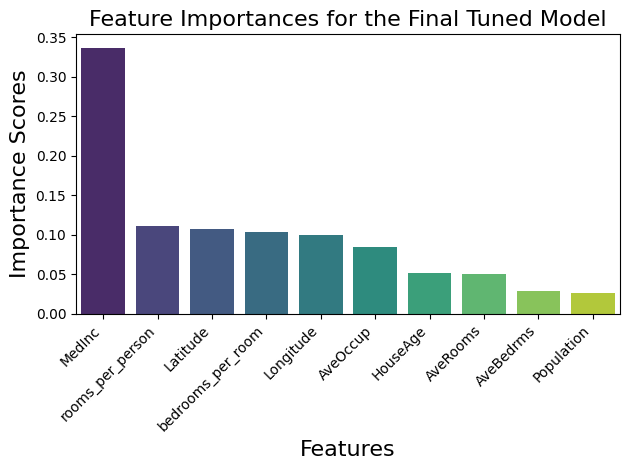

In [52]:
# Visualising feature importances using bar chart

plt.Figure(figsize=(12,8))

sns.barplot(x=sorted_feature_importances.index, y=sorted_feature_importances.values, palette='viridis')

plt.title('Feature Importances for the Final Tuned Model', fontsize=16)

plt.xlabel('Features',fontsize=16)
plt.ylabel('Importance Scores',fontsize=16)

# Rotating feature names on the x-axis to prevent them from overlapping. rotation=45 rotates the labels, 
# and ha='right' aligns them nicely with the bars.
plt.xticks(rotation=45,ha='right')

plt.tight_layout()

plt.show()

In [53]:
import joblib
print("Joblib imported successfully.")

Joblib imported successfully.


In [54]:
model_filename='final_model.joblib'
print(f"Filename for the final model has been set to: '{model_filename}'")

Filename for the final model has been set to: 'final_model.joblib'


In [55]:
# The first argument is the Python object we want to save (our final, tuned model).
# The second argument is the string containing the path and filename for the output file.

joblib.dump(final_model,model_filename)
print(f"Final model has been successfully saved to the file: '{model_filename}'")

Final model has been successfully saved to the file: 'final_model.joblib'


In [56]:
scaler_filename='scaler.joblib' 
print(f"Filename for the fitted scaler has been set to: '{scaler_filename}'")

Filename for the fitted scaler has been set to: 'scaler.joblib'


In [57]:
joblib.dump(scalar,scaler_filename)
print(f"Fitted scaler has been successfully saved to the file: '{scaler_filename}'")

Fitted scaler has been successfully saved to the file: 'scaler.joblib'


In [58]:
# Use joblib.load() to deserialize the files and bring the objects back into memory.

loaded_model = joblib.load('final_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')

print("--- Assets Loaded Successfully ---")
print("Loaded Model:", loaded_model)
print("Loaded Scaler:", loaded_scaler)

# Preparing Sample Raw Data Point
# We will take the first row of our unscaled test set (X_test) as a sample.
# .iloc[0] selects the first row. We convert it to a DataFrame to keep its structure.

sample_raw_data = X_test.iloc[[0]]

print("\n--- Raw Sample Data (Simulating User Input) ---")
display(sample_raw_data)

# Transforming the Sample Data with the Loaded Scaler 
# We use the .transform() method of our loaded_scaler.
# This applies the exact same scaling that was used on the original training data.
sample_scaled_data = loaded_scaler.transform(sample_raw_data)

print("\n--- Scaled Sample Data (Ready for the Model) ---")
print(sample_scaled_data)

# Make a Prediction with the Loaded Model
# We use the .predict() method of our loaded_model on the now-scaled sample data.
prediction = loaded_model.predict(sample_scaled_data)

# Display the Result and Verify 
# The prediction will be an array with one value. We extract it using [0].
predicted_price = prediction[0]

# Get the actual price for this same house from the y_test Series.
actual_price = y_test.iloc[0]

print("\n--- Verification Complete ---")
print(f"Prediction for the sample house: ${predicted_price:,.2f} (in hundreds of thousands)")
print(f"Actual price for the sample house: ${actual_price:,.2f} (in hundreds of thousands)")
print("\nSuccess! The loaded model and scaler are working correctly.")

--- Assets Loaded Successfully ---
Loaded Model: RandomForestRegressor(max_depth=100, max_features='sqrt', n_estimators=200,
                      n_jobs=1, random_state=42)
Loaded Scaler: StandardScaler()

--- Raw Sample Data (Simulating User Input) ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,rooms_per_person,bedrooms_per_room
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,1.081178,0.243854



--- Scaled Sample Data (Ready for the Model) ---
[[-1.15508475 -0.28632369 -0.52068576 -0.17174603 -0.03030109  0.06740798
   0.1951      0.28534728 -0.79891411  0.53446979]]

--- Verification Complete ---
Prediction for the sample house: $0.49 (in hundreds of thousands)
Actual price for the sample house: $0.48 (in hundreds of thousands)

Success! The loaded model and scaler are working correctly.


C:\Users\Varad Dalvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
